# 03 SHAP Analysis

In [1]:
%matplotlib inline
import os, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd() / "notebooks" / "models", Path.cwd().parent / "models"]:
    if (candidate / "data_loader_00.py").exists():
        candidate_str = str(candidate.resolve())
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from data_loader_00 import PROJECT_DIR, load_processed_data, get_Xy

In [2]:
def _sample_rows(X: np.ndarray, max_rows: int = 1000, seed: int = 42):
    if len(X) <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_rows, replace=False)
    return X[idx]

def shap_tree_model(model, X_test: np.ndarray, feature_names: list):
    X_use = _sample_rows(X_test)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_use)
    mean_abs = np.abs(shap_values).mean(axis=0)
    return dict(zip(feature_names, mean_abs))

In [3]:
train, valid, test, feature_cols = load_processed_data(valid_weeks=8)
X_te, y_te = get_Xy(test, feature_cols)
shap_summaries = {}

rf_path = os.path.join(os.getcwd(), "outputs", "rf_pooled_best_model.joblib")
if os.path.exists(rf_path):
    rf = joblib.load(rf_path)
    shap_summaries["RandomForest"] = shap_tree_model(rf, X_te, feature_cols)

lgbm_path = os.path.join(os.getcwd(), "outputs", "lgbm_pooled_best_model.joblib")
if os.path.exists(lgbm_path):
    lgbm = joblib.load(lgbm_path)
    shap_summaries["LightGBM"] = shap_tree_model(lgbm, X_te, feature_cols)

print(shap_summaries.keys())

[load] Train=6,270 | Valid=240 | Test=240 | Features=23
dict_keys(['RandomForest', 'LightGBM'])


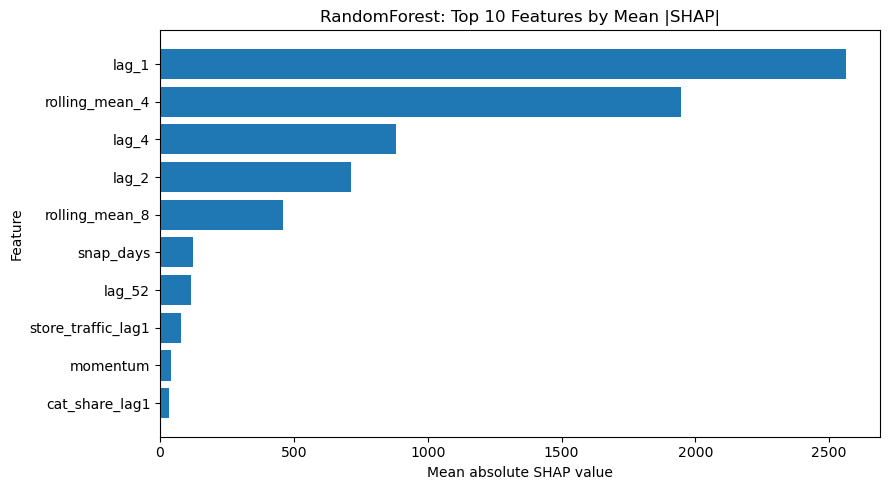

In [4]:
model_name = "RandomForest" if "RandomForest" in shap_summaries else list(shap_summaries.keys())[0]
shap_series = pd.Series(shap_summaries[model_name]).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(shap_series.index[::-1], shap_series.values[::-1])
plt.title(f"{model_name}: Top 10 Features by Mean |SHAP|")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()